In [1]:
import pandas as pd 
import numpy as np

# Plots

In [2]:
df = pd.read_csv('../../data/raw/extracted_peptides.csv')

In [3]:
df.head()

,sequence,target_activity_name,activity_measure_group,unit,activity
0,LFIFFF,Staphylococcus aureus,IC50,µg/ml,6.00000
1,LFIFFF,Staphylococcus aureus,MIC,µg/ml,15.00000
2,LFIFFF,Streptococcus sanguinis,IC50,µg/ml,1.70000
3,LFIFFF,Streptococcus sanguinis,MIC,µg/ml,5.00000
4,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,MIC,µM,165.22899


### Logarithmic Distribution of Peptide Activity

/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


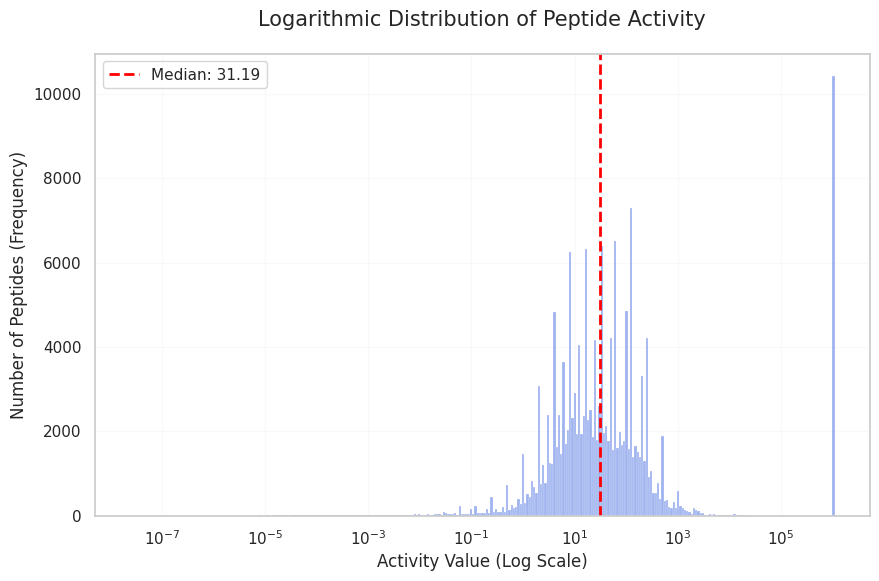

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# 1. Create the plot with specific binning and styling
ax = sns.histplot(
    data=df, 
    x='activity', 
    log_scale=True, 
    kde=True, 
    color='royalblue', 
    edgecolor='white',
    line_kws={'linewidth': 3} # Make the KDE line thicker
)

# 2. Add a vertical line for the Median
median_val = df['activity'].median()
plt.axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')

# 3. Enhance Labels and Title
plt.title('Logarithmic Distribution of Peptide Activity', fontsize=15, pad=20)
plt.xlabel('Activity Value (Log Scale)', fontsize=12)
plt.ylabel('Number of Peptides (Frequency)', fontsize=12)

# 4. Add a legend to explain the red line
plt.legend()

# 5. Add minor gridlines to help read the log scale
plt.grid(True, which="both", ls="-", alpha=0.1)

plt.show()

### Log-Scaled Frequency of Activity Measure Groups

/tmp/ipykernel_5728/2998235773.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='activity_measure_group', order=order, ax=ax, palette='viridis')


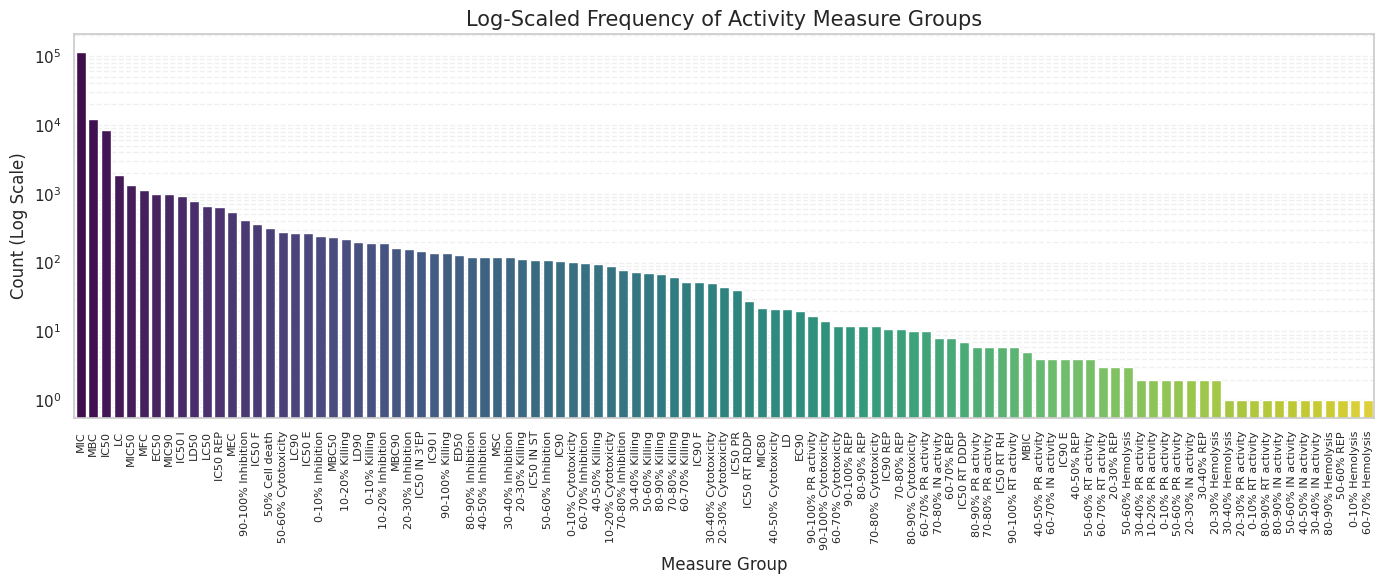

In [5]:
# Create the figure
fig, ax = plt.subplots(figsize=(14, 6))

# Sort data first to make the plot cleaner
order = df['activity_measure_group'].value_counts().index

sns.countplot(data=df, x='activity_measure_group', order=order, ax=ax, palette='viridis')

# APPLY LOG SCALE FOR CLARITY
ax.set_yscale("log")

# Styling
ax.set_title('Log-Scaled Frequency of Activity Measure Groups', fontsize=15)
ax.set_xlabel('Measure Group', fontsize=12)
ax.set_ylabel('Count (Log Scale)', fontsize=12)

# Rotate labels because there are many categories
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', which="both", linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Activity Distribution for Top 20 Measure Groups (Sorted by Median)

/tmp/ipykernel_5728/2863794285.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


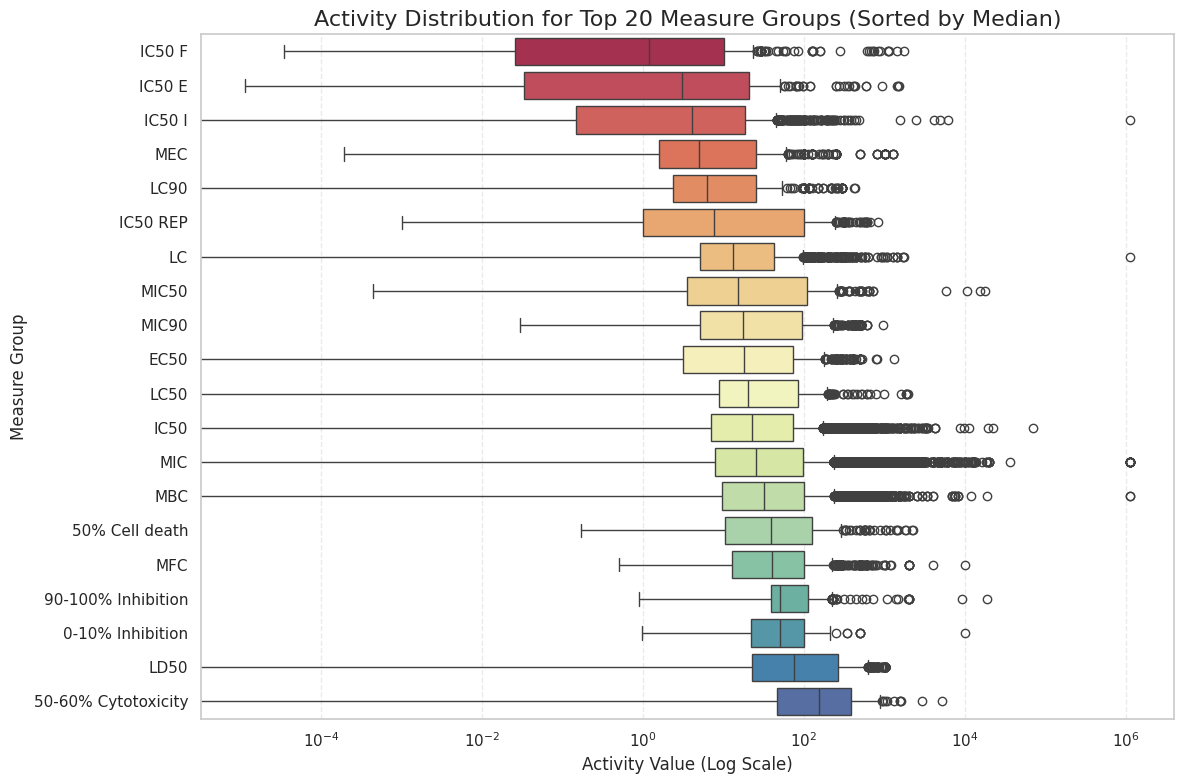

In [6]:
# 1. Filter for the top 15 most frequent measure groups to reduce noise
top_20 = df['activity_measure_group'].value_counts().nlargest(20).index
df_filtered = df[df['activity_measure_group'].isin(top_20)]

# 2. Sort the groups by their median activity value for better visual comparison
order = df_filtered.groupby('activity_measure_group')['activity'].median().sort_values().index

plt.figure(figsize=(12, 8))

# 3. Create a Horizontal Boxplot
sns.boxplot(
    data=df_filtered, 
    y='activity_measure_group', 
    x='activity', 
    order=order, 
    palette='Spectral'
)

# 4. Apply Log Scale to the Activity axis
plt.xscale('log')

# 5. Styling and Clarity
plt.title('Activity Distribution for Top 20 Measure Groups (Sorted by Median)', fontsize=16)
plt.xlabel('Activity Value (Log Scale)', fontsize=12)
plt.ylabel('Measure Group', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4) # Add faint gridlines for the log scale

plt.tight_layout()
plt.show()

/tmp/ipykernel_5728/3857158281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df[df['activity_measure_group'].isin(order)],


Text(0.5, 1.0, 'Activity Distribution across Top 20 Measures (Sorted by Median)')

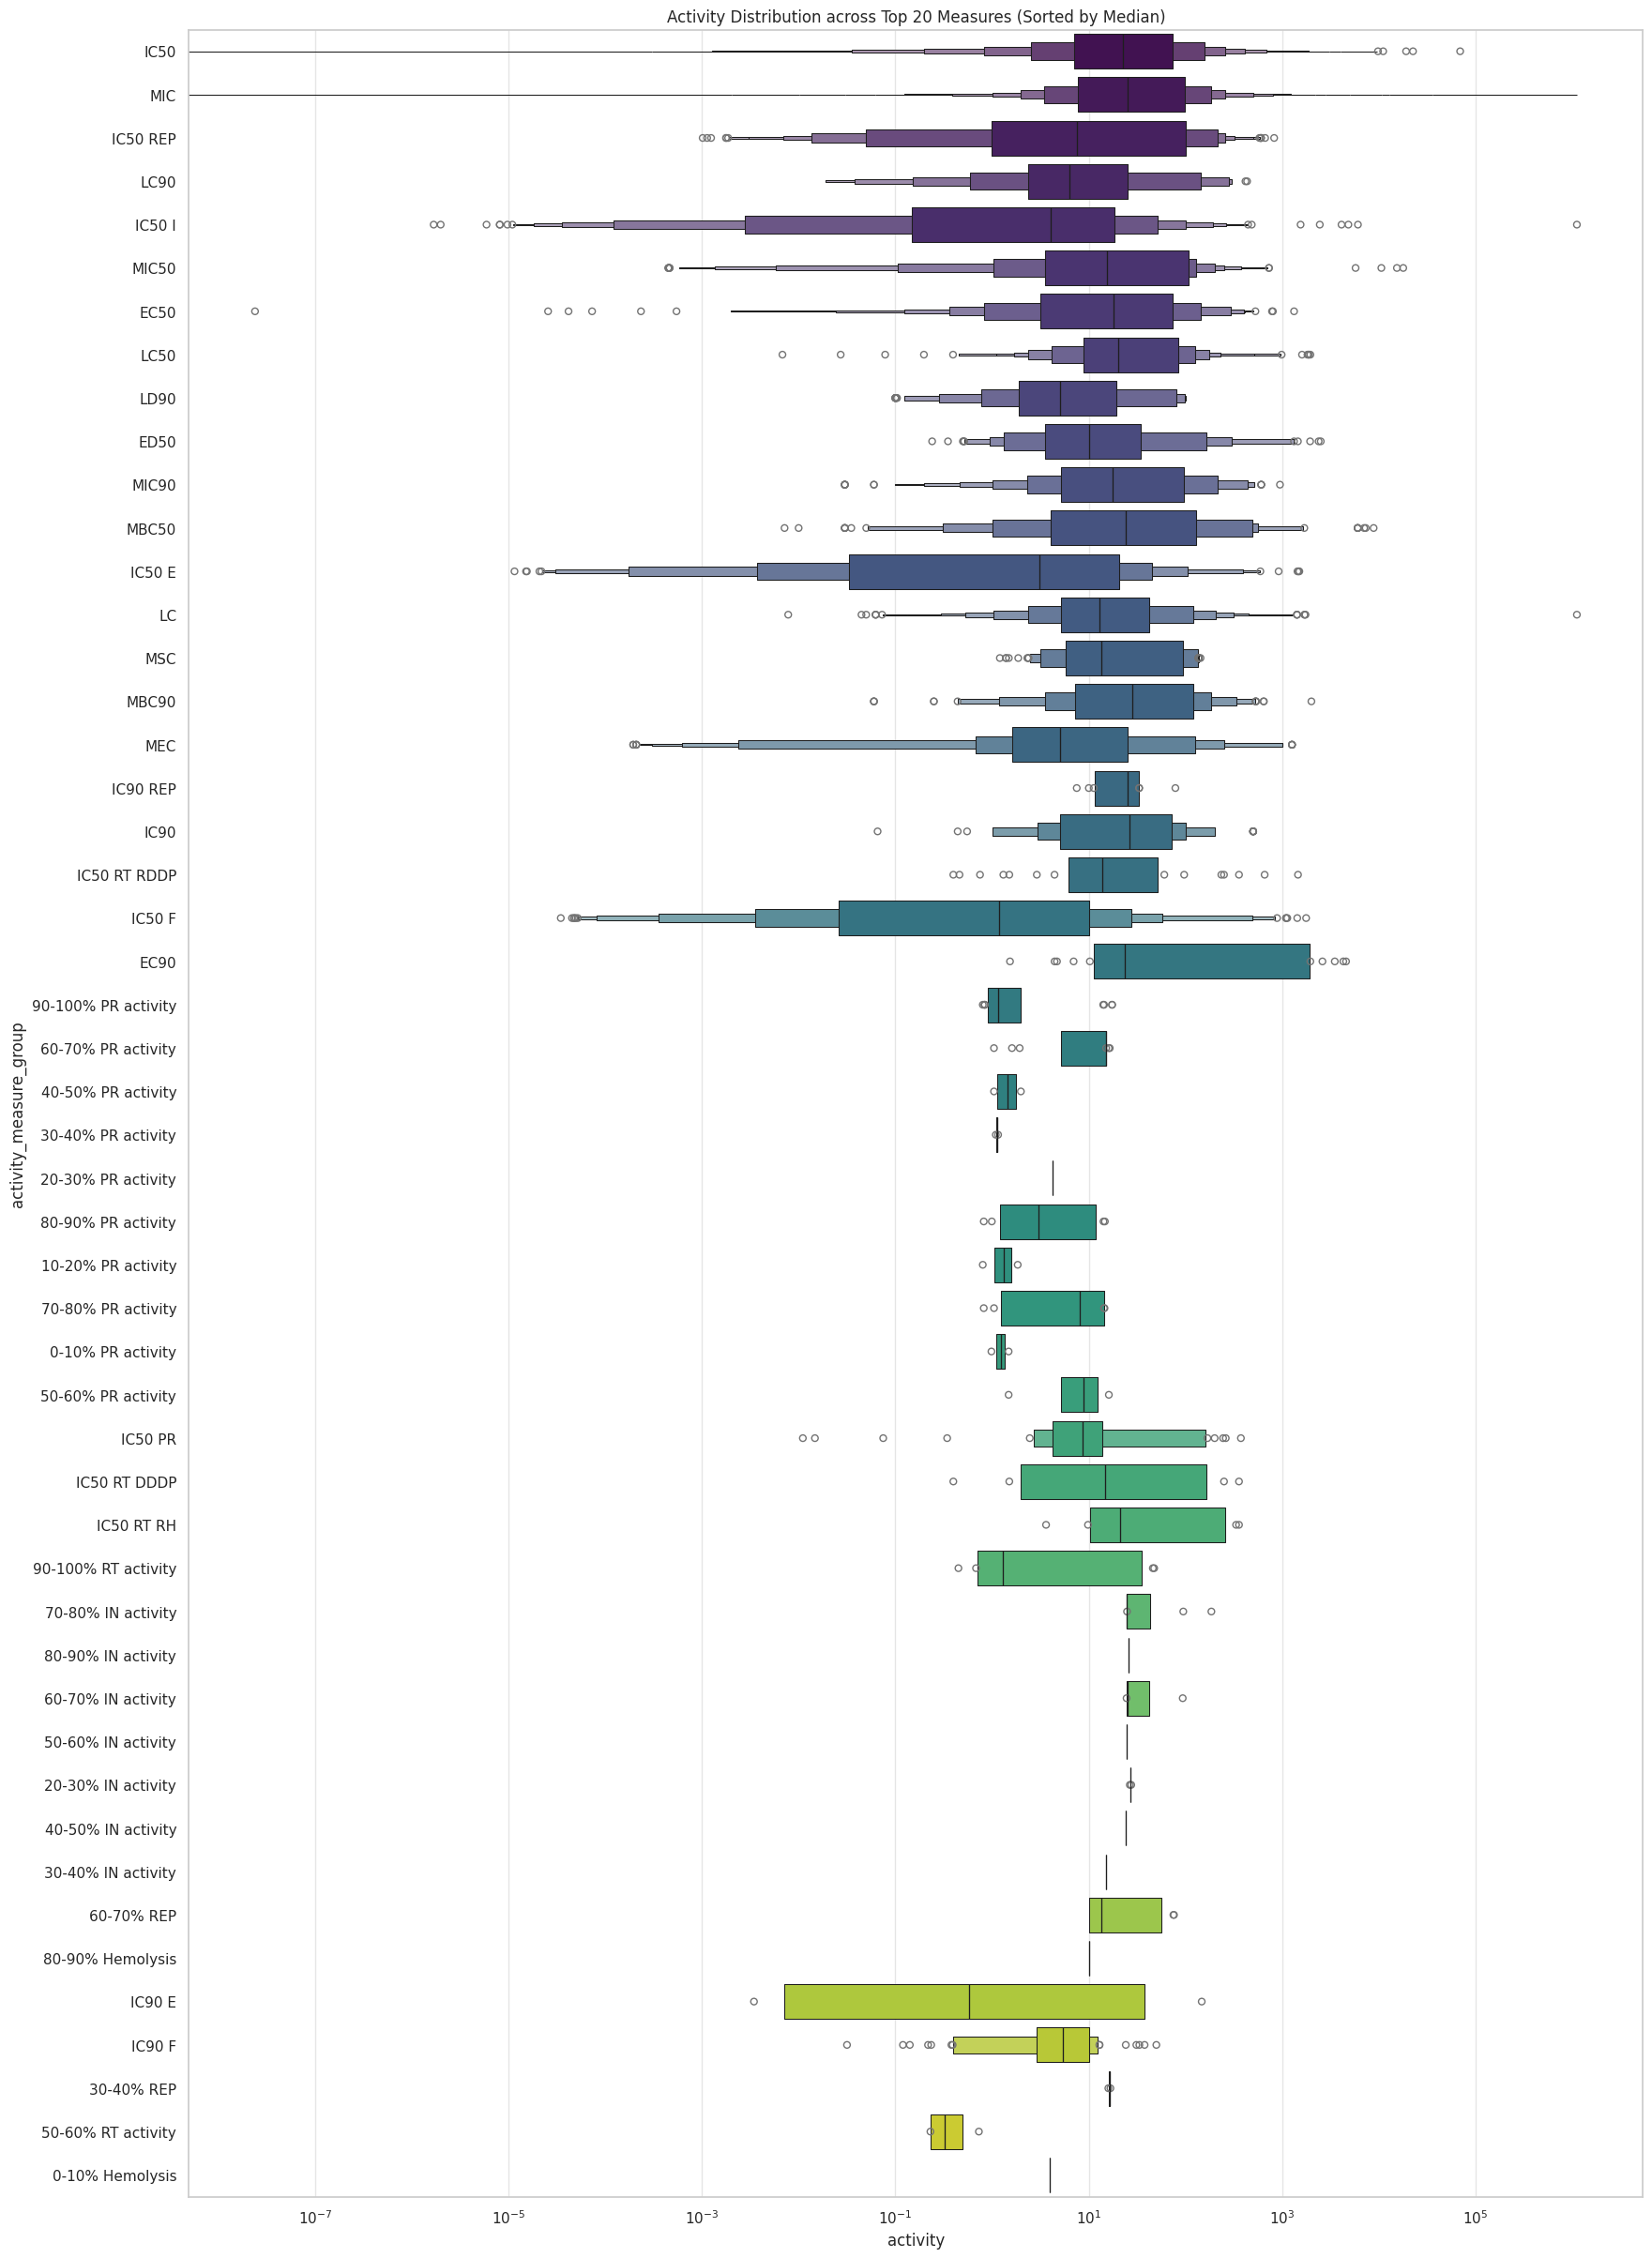

In [7]:
plt.figure(figsize=(20, 30))
# Sort by median activity to make the plot easier to read
order = df.groupby('activity_measure_group')['activity'].median().sort_values().index[:50]

sns.boxenplot(data=df[df['activity_measure_group'].isin(order)], 
              x='activity', y='activity_measure_group', palette="viridis")
plt.xscale('log')
plt.title('Activity Distribution across Top 20 Measures (Sorted by Median)')

### Activity Distribution Across Top 5 Species

/tmp/ipykernel_5728/3214413036.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


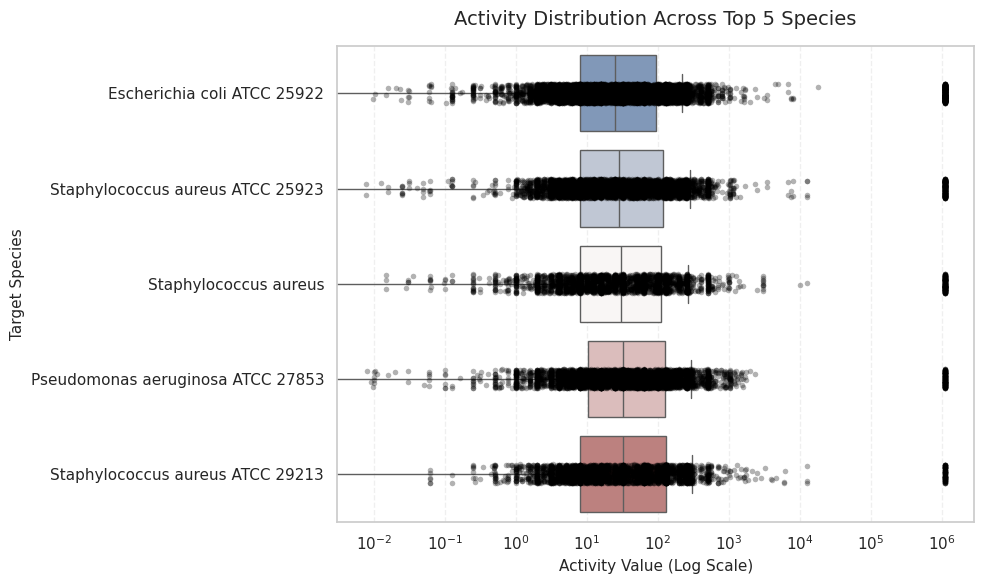

In [8]:
# 1. Identify and filter for Top 5 species
top_species = df['target_activity_name'].value_counts().nlargest(5).index
filtered_df = df[df['target_activity_name'].isin(top_species)].copy()

# 2. Sort species by median activity (potency)
# This ensures the most "sensitive" species are at the top or bottom
species_order = filtered_df.groupby('target_activity_name')['activity'].median().sort_values().index

plt.figure(figsize=(10, 6))

# 3. Draw the Boxplot
sns.boxplot(
    data=filtered_df, 
    y='target_activity_name', 
    x='activity', 
    order=species_order,
    palette='vlag',
    fliersize=0  # Hide outliers here because we will plot all points next
)

# 4. Add a Strip Plot (overlays individual data points)
sns.stripplot(
    data=filtered_df, 
    y='target_activity_name', 
    x='activity', 
    order=species_order,
    color='black', 
    alpha=0.3,   # Make points transparent so they don't hide the box
    size=4
)

# 5. Apply Log Scale
plt.xscale('log')

# 6. Formatting
plt.title('Activity Distribution Across Top 5 Species', fontsize=14, pad=15)
plt.xlabel('Activity Value (Log Scale)', fontsize=11)
plt.ylabel('Target Species', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Distribution of Target Species (Target Activity Name)

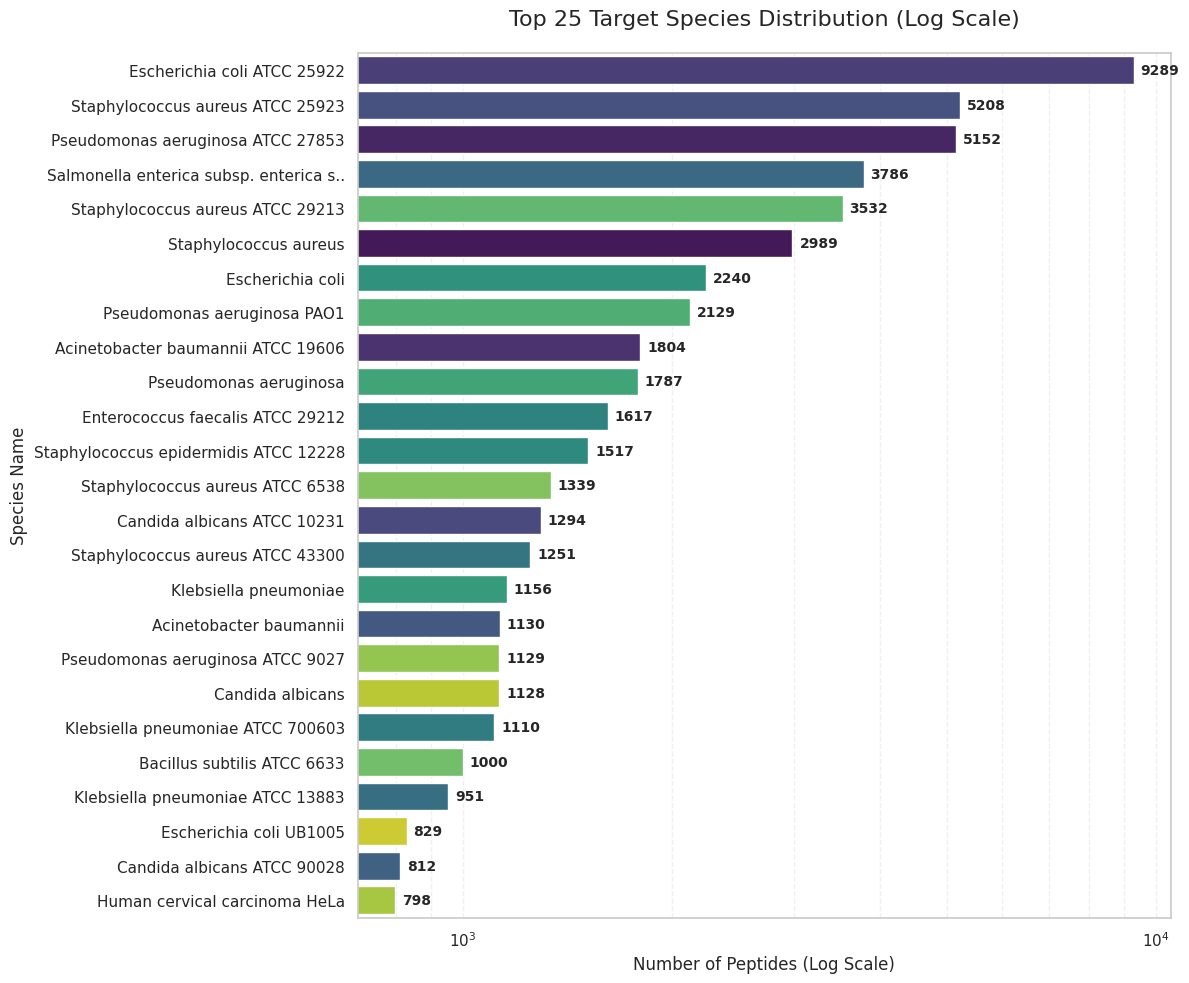

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean and Truncate names for better display
df['target_activity_name'] = df['target_activity_name'].str.replace('\t', ' ', regex=False).str.strip()

# Optional: Truncate names longer than 40 characters so they don't squash the plot
df['display_name'] = df['target_activity_name'].apply(
    lambda x: (str(x)[:37] + '..') if (isinstance(x, str) and len(x) > 40) else str(x)
)

# 2. Filter for Top 25 (otherwise the labels become unreadable)
top_n = 25
order = df['display_name'].value_counts().nlargest(top_n).index
filtered_df = df[df['display_name'].isin(order)]

# 3. Create the figure
plt.figure(figsize=(12, 10)) # Increased height for more categories

ax = sns.countplot(
    data=filtered_df, 
    y='display_name',
    hue='display_name',
    legend=False,
    palette='viridis',
    order=order
)

# 4. Apply Log Scale to the X-axis
ax.set_xscale("log")

# 5. Add exact count labels to the end of each bar
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Avoid labeling empty/zero bars
        ax.annotate(f'{int(width)}', 
                    (width, p.get_y() + p.get_height() / 2), 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    ha='left', va='center', 
                    fontsize=10, fontweight='bold')

# 6. Final Styling
plt.title(f'Top {top_n} Target Species Distribution (Log Scale)', fontsize=16, pad=20)
plt.xlabel('Number of Peptides (Log Scale)', fontsize=12)
plt.ylabel('Species Name', fontsize=12)
plt.grid(axis='x', which="both", linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Distribution of Measurement Units

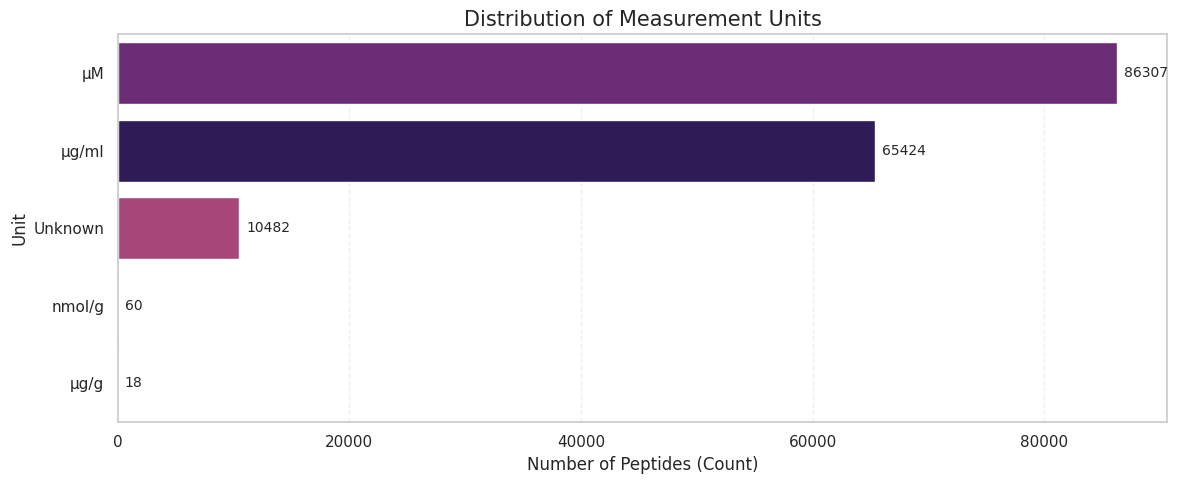

In [10]:
# 1. Clean data: handle NaNs and convert to string
df['unit'] = df['unit'].fillna('Unknown').astype(str).str.strip()

# 2. Get the order (most frequent to least)
unit_order = df['unit'].value_counts().index

plt.figure(figsize=(12, 5))

# 3. Create the plot
ax = sns.countplot(
    data=df, 
    y='unit', 
    order=unit_order, 
    palette='magma',
    hue='unit',
    legend=False
)

# 4. Apply Log Scale to make rare units visible
# ax.set_xscale('log')

# 5. Add exact count labels at the end of bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{int(width)}', 
                    (width, p.get_y() + p.get_height() / 2), 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    ha='left', va='center', 
                    fontsize=10)

plt.title('Distribution of Measurement Units', fontsize=15)
plt.xlabel('Number of Peptides (Count)', fontsize=12)
plt.ylabel('Unit', fontsize=12)
plt.grid(axis='x', which="both", linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Proportion of Activity Data (Top 10 vs Others)

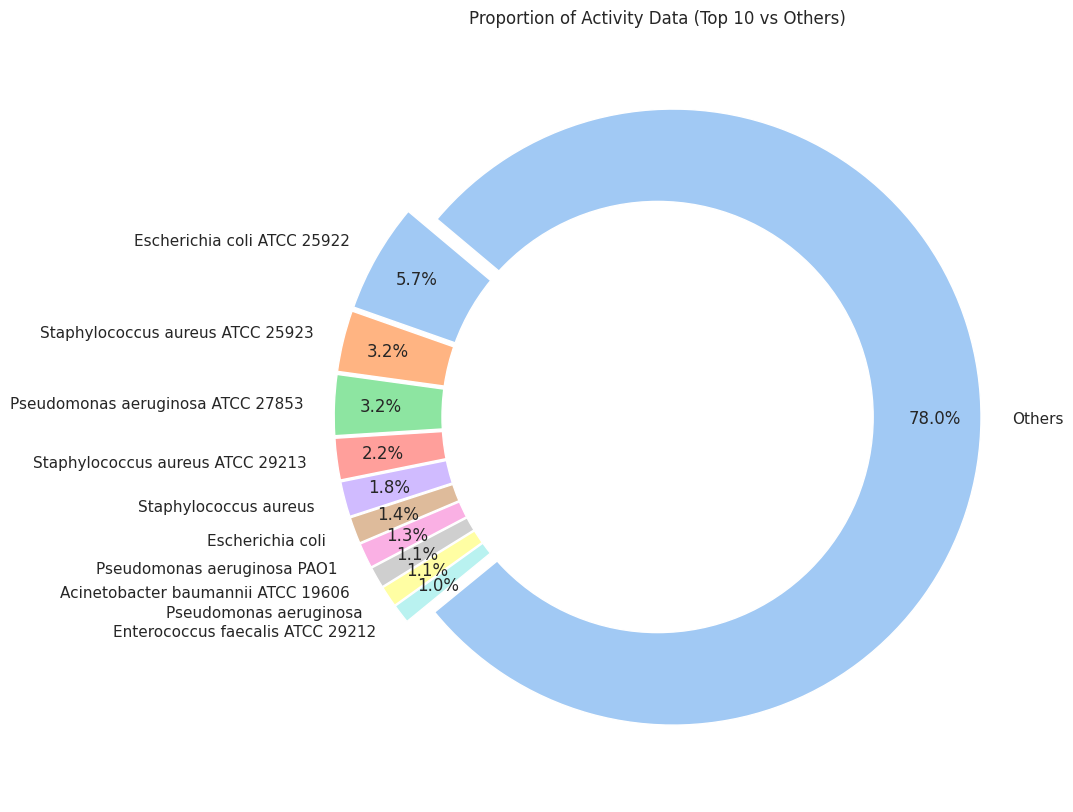

In [11]:
# 1. Get counts and separate Top 10 from the rest
counts = df['target_activity_name'].value_counts()
top_10 = counts.head(10)
others_count = counts.iloc[10:].sum()

# 2. Combine into a new Series
plot_data = pd.concat([top_10, pd.Series({'Others': others_count})])

# 3. Plot with improved label handling
plt.figure(figsize=(12, 10))
plt.pie(
    plot_data, 
    labels=plot_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel'),
    pctdistance=0.85, # Moves the percentages further out
    explode=[0.05] * len(plot_data) # Adds a small gap between slices for clarity
)

# Draw a circle at the center to turn it into a Donut Chart (optional but looks cleaner)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proportion of Activity Data (Top 10 vs Others)')
plt.show()

### Distribution of Peptide Sequence Lengths

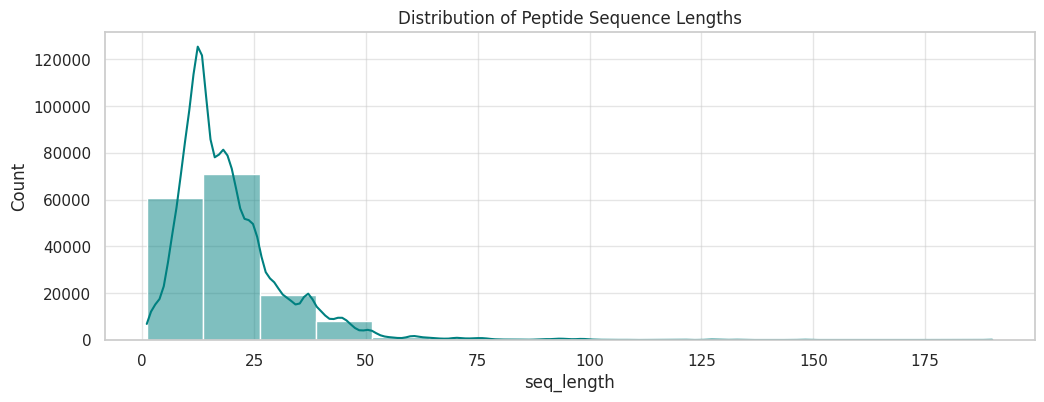

In [12]:
df['seq_length'] = df['sequence'].str.len()

plt.figure(figsize=(12, 4))
sns.histplot(df['seq_length'], bins=15, kde=True, color='teal')
plt.title('Distribution of Peptide Sequence Lengths')
plt.show()

### Pareto Analysis with Cumulative Labels

/tmp/ipykernel_5728/3942246681.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='measure', y='count', ax=ax1, palette='Blues_r')


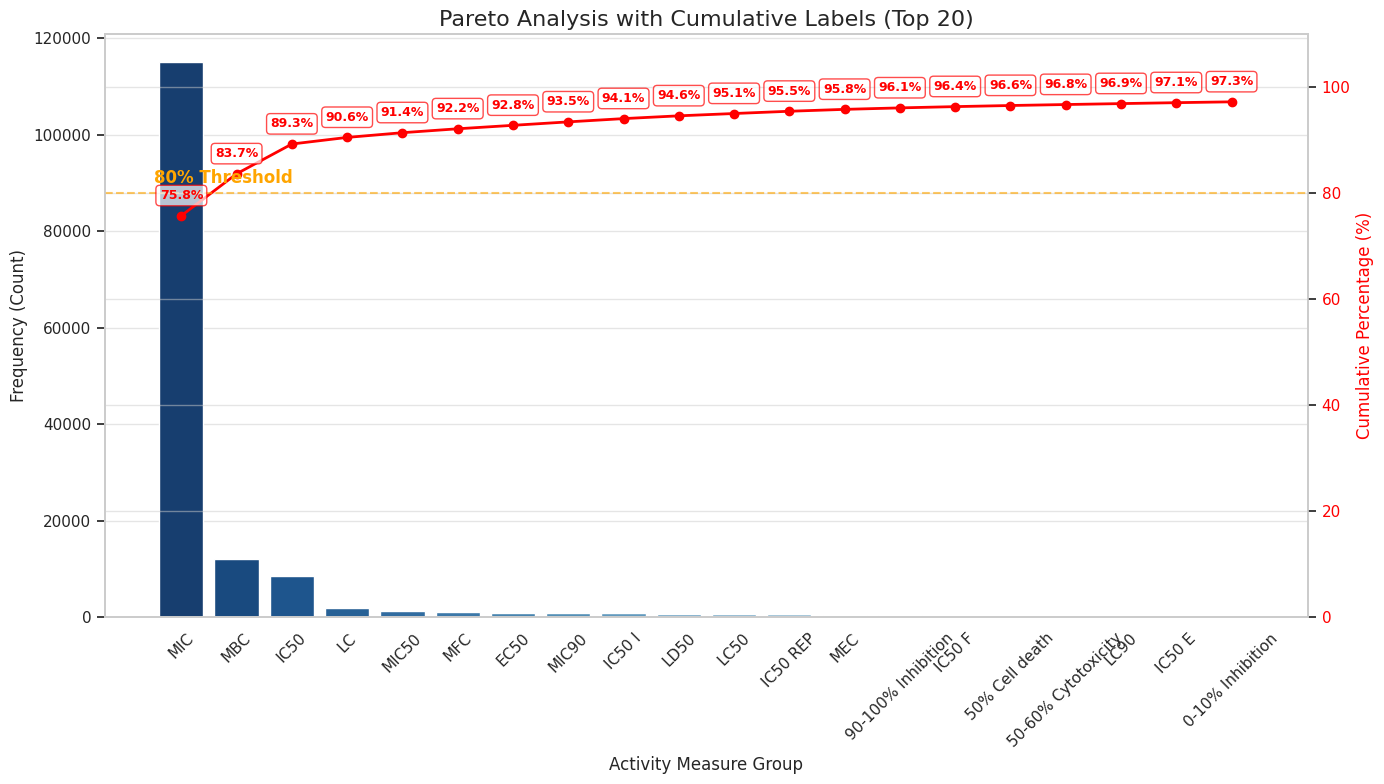

In [13]:

# 1. Prepare the data
counts = df['activity_measure_group'].value_counts().reset_index()
counts.columns = ['measure', 'count']

# Calculate cumulative percentage
total_count = counts['count'].sum()
counts['cum_percent'] = (counts['count'].cumsum() / total_count) * 100

# Slice for the Top 20 for better visibility
top_n = 20
plot_df = counts.head(top_n)

# 2. Initialize the plot
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot the bars (Frequencies)
sns.barplot(data=plot_df, x='measure', y='count', ax=ax1, palette='Blues_r')
ax1.set_ylabel('Frequency (Count)', fontsize=12)
ax1.set_xlabel('Activity Measure Group', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# 3. Create the secondary Y-axis for the cumulative percentage
ax2 = ax1.twinx()
ax2.plot(plot_df['measure'], plot_df['cum_percent'], color='red', marker='o', linewidth=2, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12, color='red')
ax2.set_ylim(0, 110) # Set slightly higher than 100 to leave room for labels
ax2.tick_params(axis='y', labelcolor='red')

# 4. ADD NUMBERS TO THE CUMULATIVE VALUES
for i, val in enumerate(plot_df['cum_percent']):
    ax2.annotate(f'{val:.1f}%', 
                 (i, plot_df['cum_percent'].iloc[i]), 
                 textcoords="offset points", # Position relative to the point
                 xytext=(0, 12),             # 12 points vertical offset
                 ha='center',                # Horizontal alignment
                 fontsize=9, 
                 color='red', 
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.7)) # Optional background box

# 5. Add a reference line at 80%
ax2.axhline(80, color='orange', linestyle='--', alpha=0.6)
ax2.text(-0.5, 82, '80% Threshold', color='orange', fontweight='bold')

plt.title(f'Pareto Analysis with Cumulative Labels (Top {top_n})', fontsize=16)
plt.tight_layout()
plt.show()

(115078, 7)
(162291, 7)


/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


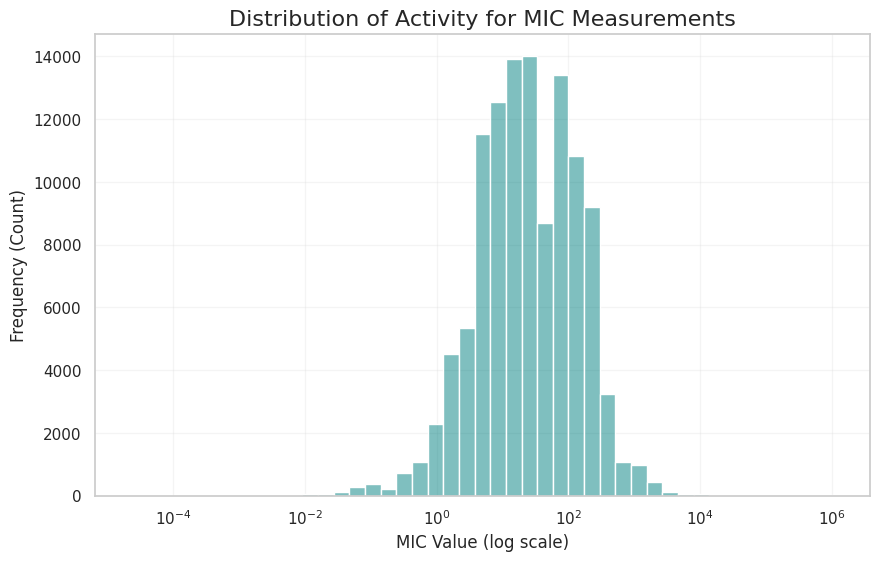

In [14]:
# 1. Filter the data for 'MIC' only
# Note: Ensure the string matches exactly what is in your CSV/DataFrame
mic_df = df[df['activity_measure_group'] == 'MIC']
print(mic_df.shape)
print(df.shape)
# 2. Create the plot
plt.figure(figsize=(10, 6))

sns.histplot(
    data=mic_df, 
    x='activity', 
    log_scale=True,   # Essential for MIC data
    kde=True,         # Adds the Kernel Density Estimate line
    bins=45,
    color='teal',
    edgecolor='white'
)

# 3. Enhance the labels
plt.title('Distribution of Activity for MIC Measurements', fontsize=16)
plt.xlabel('MIC Value (log scale)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

# Optional: Add gridlines for better readability on log scale
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

### Activity Distributions for Top 10 Measure Groups

/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/zaza-elizbarashvili/miniconda

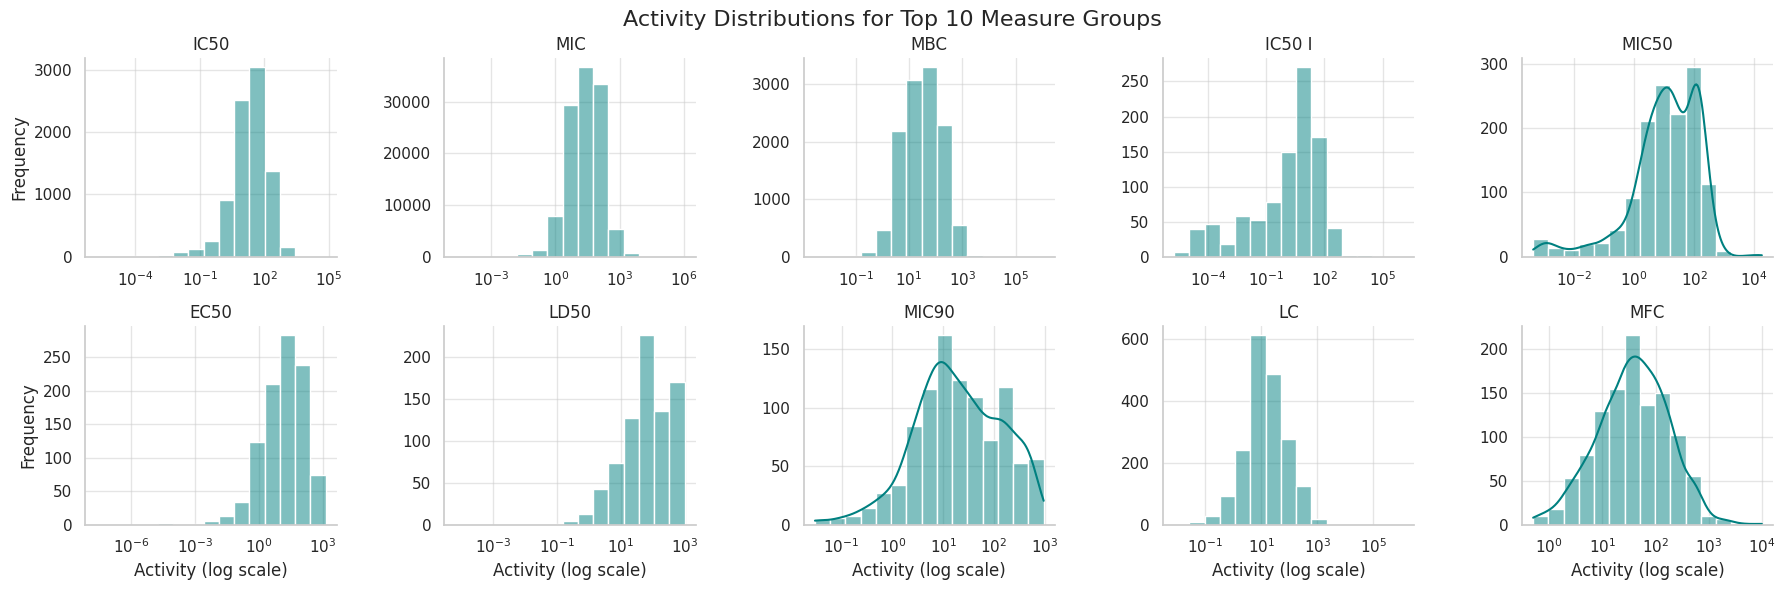

In [15]:
# 1. Identify the Top 10 activity measure groups
top_10_measures = df['activity_measure_group'].value_counts().nlargest(10).index

# 2. Filter the dataframe to include only these 10 groups
df_top10 = df[df['activity_measure_group'].isin(top_10_measures)]

# 3. Create a FacetGrid (Small Multiples)
# col_wrap=5 means it will create 2 rows of 5 plots
g = sns.FacetGrid(df_top10, col="activity_measure_group", col_wrap=5, 
                  sharex=False, sharey=False, height=3, aspect=1.2)

# 4. Map the histogram/KDE to each subplot
# We use log_scale=True because activity values usually span orders of magnitude
g.map_dataframe(sns.histplot, x="activity", log_scale=True, kde=True, 
                bins=15, color='teal', edgecolor='white')

# 5. Final styling
g.set_axis_labels("Activity (log scale)", "Frequency")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Activity Distributions for Top 10 Measure Groups', fontsize=16)

plt.show()

### Frequency of Amino Acids across all Sequences

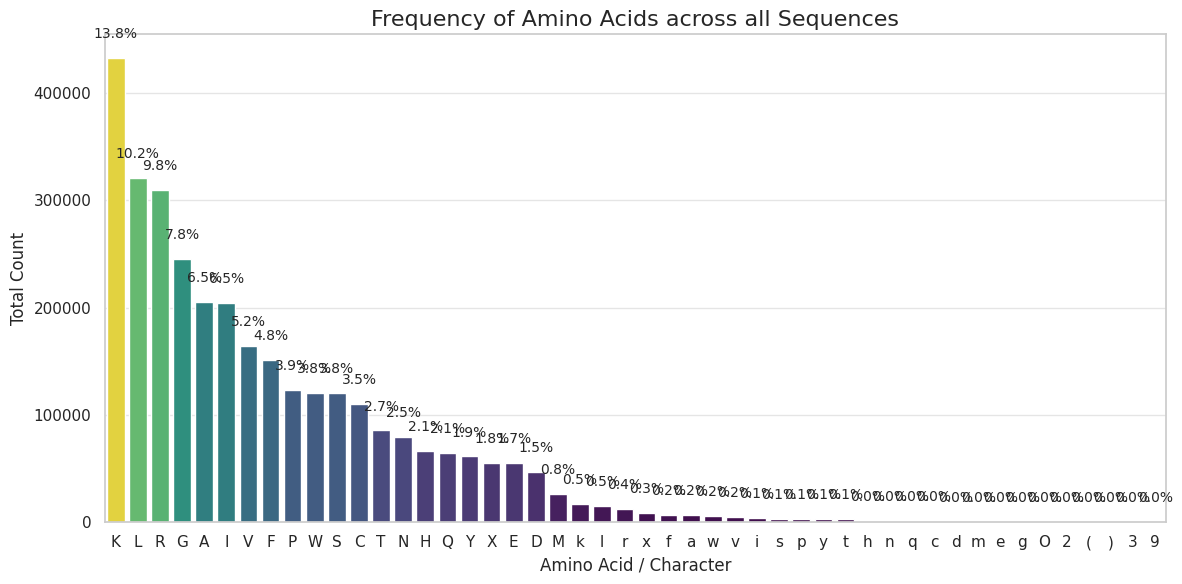

In [16]:
from collections import Counter

# 1. Combine all sequences into one single string
# We drop NA values and ensure everything is a string
all_sequences = "".join(df['sequence'].dropna().astype(str))

# 2. Count the frequency of each character
aa_counts = Counter(all_sequences)

# 3. Convert to a DataFrame for easy plotting
aa_df = pd.DataFrame.from_dict(aa_counts, orient='index').reset_index()
aa_df.columns = ['Amino_Acid', 'Count']

# 4. Sort by frequency (highest to lowest)
aa_df = aa_df.sort_values(by='Count', ascending=False)

# 5. Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(data=aa_df, x='Amino_Acid', y='Count', hue='Count', legend=False, palette='viridis')

# Add labels and title
plt.title("Frequency of Amino Acids across all Sequences", fontsize=16)
plt.xlabel("Amino Acid / Character", fontsize=12)
plt.ylabel("Total Count", fontsize=12)

# Optional: Add the percentage on top of each bar
total_aa = aa_df['Count'].sum()
for i, row in enumerate(aa_df.itertuples()):
    pct = f'{(row.Count / total_aa) * 100:.1f}%'
    plt.text(i, row.Count + (total_aa * 0.005), pct, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

<Axes: xlabel='R_percent', ylabel='Count'>

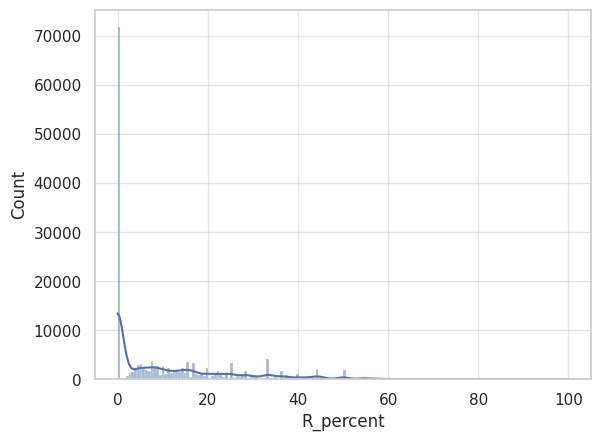

In [17]:
# Create a column for the percentage of Arginine (R) in each peptide
df['R_percent'] = df['sequence'].apply(
    lambda seq: (seq.count('R') / len(seq) * 100) if isinstance(seq, str) and len(seq) > 0 else 0
)

# You can then plot the distribution of 'R_percent'
sns.histplot(df['R_percent'], kde=True)

In [18]:
import re

# Find all unique characters in sequences
all_chars = set(''.join(df['sequence'].dropna()))

lowercase = {c for c in all_chars if c.islower()}
uppercase = {c for c in all_chars if c.isupper()}

print("Lowercase chars found:", lowercase)
print("Uppercase chars found:", uppercase)

Lowercase chars found: {'f', 's', 'q', 'g', 'p', 'a', 'k', 'x', 'h', 'r', 'd', 'n', 'v', 'e', 'i', 'c', 'm', 't', 'y', 'l', 'w'}
Uppercase chars found: {'W', 'P', 'C', 'K', 'F', 'A', 'R', 'Q', 'N', 'E', 'O', 'H', 'Y', 'M', 'D', 'L', 'I', 'G', 'X', 'V', 'S', 'T'}


# preproces data

In [19]:
df = pd.read_csv('../../data/raw/extracted_peptides.csv')

# 1. Filter the DataFrame
# This looks for rows where 'activity_measure_group' is exactly 'MIC'
mic_df = df[df['activity_measure_group'] == 'MIC'].copy()

# 2. Check the results
print(f"Original rows: {len(df)}")
print(f"MIC rows: {len(mic_df)}")

# 3. View the first few rows of the new MIC-only DataFrame
mic_df.head()

Original rows: 162291
MIC rows: 115078


,sequence,target_activity_name,activity_measure_group,unit,activity
1,LFIFFF,Staphylococcus aureus,MIC,µg/ml,15.00000
3,LFIFFF,Streptococcus sanguinis,MIC,µg/ml,5.00000
4,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,MIC,µM,165.22899
5,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,MIC,µM,165.22899
6,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,MIC,µM,165.22899


In [20]:
mic_df['unit'].unique()

<StringArray>
['µg/ml', 'µM', nan]
Length: 3, dtype: str

In [21]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import pandas as pd
import numpy as np

def calculate_mw(sequence):
    try:
        # Filter out non-standard characters like 'X' or 'B' which BioPython can't weight
        # We replace them with a neutral average if necessary, or skip
        clean_seq = ''.join([amino for amino in str(sequence).upper() if amino in "ACDEFGHIKLMNPQRSTVWY"])
        if not clean_seq:
            return np.nan
        
        analysed_seq = ProteinAnalysis(clean_seq)
        return analysed_seq.molecular_weight()
    except:
        return np.nan

# 1. Filter for rows that use µg/ml
mask = (mic_df['unit'] == 'µg/ml')

# 2. Calculate Molecular Weight for those rows
# Note: This might take a few seconds if you have thousands of rows
mic_df.loc[mask, 'MW'] = mic_df.loc[mask, 'sequence'].apply(calculate_mw)

# 3. Perform the conversion
# We multiply by 1000 to convert mg/L to µM
mic_df.loc[mask, 'activity_uM'] = (mic_df.loc[mask, 'activity'] * 1000) / mic_df.loc[mask, 'MW']

# 4. For rows already in µM, just copy the value over
mic_df.loc[mic_df['unit'] == 'µM', 'activity_uM'] = mic_df['activity']

# 5. Review the conversion
print(mic_df[['sequence', 'activity', 'unit', 'MW', 'activity_uM']])

            sequence   activity   unit        MW  activity_uM
1             LFIFFF   15.00000  µg/ml  833.0257    18.006647
3             LFIFFF    5.00000  µg/ml  833.0257     6.002216
4       KVvvKWVvKvVK  165.22899     µM       NaN   165.228990
5       KVvvKWVvKvVK  165.22899     µM       NaN   165.228990
6       KVvvKWVvKvVK  165.22899     µM       NaN   165.228990
...              ...        ...    ...       ...          ...
162286         RxXxR    1.40000  µg/ml  330.3867     4.237459
162287         RxXxR    1.40000  µg/ml  330.3867     4.237459
162288         RxXxR    5.60000  µg/ml  330.3867    16.949835
162289         RxXxR    2.80000  µg/ml  330.3867     8.474917
162290         RxXxR    5.60000  µg/ml  330.3867    16.949835

[115078 rows x 5 columns]


In [22]:
mic_df

,sequence,target_activity_name,activity_measure_group,unit,activity,MW,activity_uM
1,LFIFFF,Staphylococcus aureus,MIC,µg/ml,15.00000,833.0257,18.006647
3,LFIFFF,Streptococcus sanguinis,MIC,µg/ml,5.00000,833.0257,6.002216
4,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,MIC,µM,165.22899,NaN,165.228990
5,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,MIC,µM,165.22899,NaN,165.228990
6,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,MIC,µM,165.22899,NaN,165.228990
...,...,...,...,...,...,...,...
162286,RxXxR,Staphylococcus aureus ATCC 43300,MIC,µg/ml,1.40000,330.3867,4.237459
162287,RxXxR,Staphylococcus epidermidis ATCC 35984,MIC,µg/ml,1.40000,330.3867,4.237459
162288,RxXxR,Enterococcus faecalis ATCC 29212,MIC,µg/ml,5.60000,330.3867,16.949835
162289,RxXxR,Enterococcus faecium ATCC 700221,MIC,µg/ml,2.80000,330.3867,8.474917


In [23]:
mic_df.columns

Index(['sequence', 'target_activity_name', 'activity_measure_group', 'unit',
       'activity', 'MW', 'activity_uM'],
      dtype='str')

In [24]:
mic_df = mic_df.drop(columns=['activity_measure_group', 'MW',])

In [25]:
mic_df.isna().sum()

sequence                 16
target_activity_name      0
unit                     33
activity                  0
activity_uM             182
dtype: int64

In [26]:
mic_df[mic_df['sequence'].isna()]

,sequence,target_activity_name,unit,activity,activity_uM
39,NaN,Colletotrichum gossypii,µg/ml,37.000000,116.609475
154,NaN,Escherichia coli ATCC 25922,µM,0.261290,0.261290
155,NaN,Staphylococcus aureus ATCC 25923,µM,0.504560,0.504560
156,NaN,Pseudomonas aeruginosa ATCC 27853,µM,0.504560,0.504560
157,NaN,Enterococcus faecalis ATCC 29212,µM,0.261290,0.261290
158,NaN,Escherichia coli,µM,0.210474,0.210474
160,NaN,Klebsiella pneumoniae,µM,0.421127,0.421127
162,NaN,Serratia marcescens,µM,0.842075,0.842075
164,NaN,Stenotrophomonas maltophilia,µM,0.842976,0.842976
166,NaN,Acinetobacter baumannii,µM,0.842075,0.842075


In [27]:
# Filter for rows where activity is NOT null AND activity_uM IS null
mask = (mic_df['activity'].notna()) & (mic_df['activity_uM'].isna())

# Display the resulting rows
result = mic_df[mask]
print(result)

               sequence               target_activity_name   unit  activity  \
14872   XXXXXXXXXXXXXXX        Pseudomonas aeruginosa H103  µg/ml       4.0   
14873   XXXXXXXXXXXXXXX           Pseudomonas aeruginosa 9  µg/ml     128.0   
14874   XXXXXXXXXXXXXXX         Pseudomonas aeruginosa 198  µg/ml      16.0   
14875   XXXXXXXXXXXXXXX         Pseudomonas aeruginosa 213  µg/ml       4.0   
14876   XXXXXXXXXXXXXXX      Pseudomonas aeruginosa LES400  µg/ml       8.0   
...                 ...                                ...    ...       ...   
157535                x              Staphylococcus aureus  µg/ml      25.0   
157536                x        Escherichia coli ATCC 25922  µg/ml      12.5   
157537                x  Pseudomonas aeruginosa ATCC 27853  µg/ml      50.0   
157538                x   Cronobacter sakazakii ATCC 29544  µg/ml      50.0   
157539                x  Klebsiella pneumoniae ATCC 700603  µg/ml      50.0   

        activity_uM  
14872           NaN  
14873  

In [28]:
result

,sequence,target_activity_name,unit,activity,activity_uM
14872,XXXXXXXXXXXXXXX,Pseudomonas aeruginosa H103,µg/ml,4.0,NaN
14873,XXXXXXXXXXXXXXX,Pseudomonas aeruginosa 9,µg/ml,128.0,NaN
14874,XXXXXXXXXXXXXXX,Pseudomonas aeruginosa 198,µg/ml,16.0,NaN
14875,XXXXXXXXXXXXXXX,Pseudomonas aeruginosa 213,µg/ml,4.0,NaN
14876,XXXXXXXXXXXXXXX,Pseudomonas aeruginosa LES400,µg/ml,8.0,NaN
...,...,...,...,...,...
157535,x,Staphylococcus aureus,µg/ml,25.0,NaN
157536,x,Escherichia coli ATCC 25922,µg/ml,12.5,NaN
157537,x,Pseudomonas aeruginosa ATCC 27853,µg/ml,50.0,NaN
157538,x,Cronobacter sakazakii ATCC 29544,µg/ml,50.0,NaN


In [29]:
result['sequence'].unique()

<StringArray>
[                           'XXXXXXXXXXXXXXX',
                      'GFIFHIIKGLFHAGKMIHGLV',
 'YKQCHKKGGHCFPKEKICLPPSSDFGKMDCRWRWKCCKKGSG',
                               'XXXXXXXXXXXX',
                                          'X',
                                         'XX',
                                        'XXX',
                                       'XXXX',
                                      'XXXXX',
    'HHHLFGHVGHEVERSLHKVGHKLEHACHEVHKTAKKVQK',
                                   'XXXXXXXX',
                                  'XXXXXXXXX',
                      'KLLKKAGKLLKKAGKLLKKAG',
                  'AGKEKIRKKLKNEIKKKGRKAVIAW',
                      'FIHHIIGWISHGVRAIHRAIH',
                              'FKRIVQRILDFLR',
                              'YEESQAELEGSLK',
            'KVNHAACAAHCLLKRKRGGYCNKRRICVCRN',
                'KFAKFAKKFAKFAKGGRPKPQQFFGLM',
                     'IASKFLCTPGCAKXGSFNSYCC',
                                        'XXQ',

In [30]:
result[result['sequence'] == 'YKQCHKKGGHCFPKEKICLPPSSDFGKMDCRWRWKCCKKGSG']

,sequence,target_activity_name,unit,activity,activity_uM
32477,YKQCHKKGGHCFPKEKICLPPSSDFGKMDCRWRWKCCKKGSG,Providencia rettgeri,NaN,1111111.0,NaN
32478,YKQCHKKGGHCFPKEKICLPPSSDFGKMDCRWRWKCCKKGSG,Serratia marcescens,NaN,1111111.0,NaN
32479,YKQCHKKGGHCFPKEKICLPPSSDFGKMDCRWRWKCCKKGSG,Morganella morganii,NaN,1111111.0,NaN
32480,YKQCHKKGGHCFPKEKICLPPSSDFGKMDCRWRWKCCKKGSG,Klebsiella pneumoniae,NaN,1111111.0,NaN


In [31]:
result['unit'].unique()

<StringArray>
['µg/ml', nan]
Length: 2, dtype: str

In [32]:
mic_df = mic_df.dropna()

In [33]:
display(mic_df)

,sequence,target_activity_name,unit,activity,activity_uM
1,LFIFFF,Staphylococcus aureus,µg/ml,15.00000,18.006647
3,LFIFFF,Streptococcus sanguinis,µg/ml,5.00000,6.002216
4,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,µM,165.22899,165.228990
5,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,µM,165.22899,165.228990
6,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,µM,165.22899,165.228990
...,...,...,...,...,...
162286,RxXxR,Staphylococcus aureus ATCC 43300,µg/ml,1.40000,4.237459
162287,RxXxR,Staphylococcus epidermidis ATCC 35984,µg/ml,1.40000,4.237459
162288,RxXxR,Enterococcus faecalis ATCC 29212,µg/ml,5.60000,16.949835
162289,RxXxR,Enterococcus faecium ATCC 700221,µg/ml,2.80000,8.474917


In [34]:
mic_df = mic_df.drop(columns=['unit', 'activity'])

In [35]:
mic_df = mic_df.rename(columns={'activity_uM': 'activity'})

In [36]:
mic_df.isna().sum()

sequence                0
target_activity_name    0
activity                0
dtype: int64

In [37]:
# 4. Export to CSV
mic_df.to_csv('../../data/raw/amp_mic_activities.csv', index=False)

# Display the output in Notebook
display(mic_df)

,sequence,target_activity_name,activity
1,LFIFFF,Staphylococcus aureus,18.006647
3,LFIFFF,Streptococcus sanguinis,6.002216
4,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.228990
5,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.228990
6,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.228990
...,...,...,...
162286,RxXxR,Staphylococcus aureus ATCC 43300,4.237459
162287,RxXxR,Staphylococcus epidermidis ATCC 35984,4.237459
162288,RxXxR,Enterococcus faecalis ATCC 29212,16.949835
162289,RxXxR,Enterococcus faecium ATCC 700221,8.474917


# AMP datafarme

In [38]:
amp_df = pd.read_csv('../../data/raw/amp_mic_activities.csv')

display(amp_df)

,sequence,target_activity_name,activity
0,LFIFFF,Staphylococcus aureus,18.006647
1,LFIFFF,Streptococcus sanguinis,6.002216
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.228990
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.228990
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.228990
...,...,...,...
114875,RxXxR,Staphylococcus aureus ATCC 43300,4.237459
114876,RxXxR,Staphylococcus epidermidis ATCC 35984,4.237459
114877,RxXxR,Enterococcus faecalis ATCC 29212,16.949835
114878,RxXxR,Enterococcus faecium ATCC 700221,8.474917


In [39]:
amp_df['target_activity_name'].unique()

<StringArray>
[                 'Staphylococcus aureus',
                'Streptococcus sanguinis',
       'Staphylococcus aureus ATCC 6538P',
            'Bacillus subtilis ATCC 6051',
      'Pseudomonas aeruginosa ATCC 27853',
     'Acinetobacter baumannii ATCC 19606',
            'Escherichia coli ATCC 25922',
            'Candida albicans ATCC 10231',
   'Cryptococcus neoformans ATCC MYA-422',
       'Aspergillus fumigatus ATCC 26430',
 ...
        'Enterobacter cloacae ATCC 14037',
              'Enterococcus faecium EF18',
            'Enterococcus faecalis AR785',
          'Enterococcus gallinarum AR784',
       'Enterococcus casseliflavus AR798',
          'Clostridioides difficile HM89',
 'Streptococcus agalactiae ATCC BAA-2675',
                     'Enterovirus EV-A71',
    'Lacticaseibacillus casei ATCC 15008',
          'Lactococcus lactis ATCC 15346']
Length: 5811, dtype: str

In [40]:
target_species = [
    'Escherichia coli', 
    'Pseudomonas aeruginosa', 
    'Klebsiella pneumoniae', 
    'Staphylococcus aureus', 
    'Bacillus subtilis'
]

In [41]:
def standardize_name(name):
    if not isinstance(name, str):
        return "Other"
    
    for species in target_species:
        if species.lower() in name.lower():
            return species  # Returns the clean name if found
    return "Other" # Or return name if you want to keep the original for non-targets

# Apply the function to create a new grouping column
amp_df['clean_target'] = amp_df['target_activity_name'].apply(standardize_name)

In [42]:
display(amp_df)

,sequence,target_activity_name,activity,clean_target
0,LFIFFF,Staphylococcus aureus,18.006647,Staphylococcus aureus
1,LFIFFF,Streptococcus sanguinis,6.002216,Other
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.228990,Staphylococcus aureus
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.228990,Bacillus subtilis
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.228990,Pseudomonas aeruginosa
...,...,...,...,...
114875,RxXxR,Staphylococcus aureus ATCC 43300,4.237459,Staphylococcus aureus
114876,RxXxR,Staphylococcus epidermidis ATCC 35984,4.237459,Other
114877,RxXxR,Enterococcus faecalis ATCC 29212,16.949835,Other
114878,RxXxR,Enterococcus faecium ATCC 700221,8.474917,Other
